In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# !pip install --upgrade certifi

In [3]:
# !pip install gtts pydub audioop-lts
# !pip install --upgrade certifi # added certifi-2025.10.5, though check https://api.msedgeservices.com
import time
import os
import pandas as pd
from collections import defaultdict
from PIL import Image, ImageDraw, ImageFont
from moviepy import ImageClip
from utils_data import (
    load_raw_data, check_dups, filter_df_to_vocab_of_interest, 
    fill_default_settings, delete_previous_attempt_files
    )
from utils_video import (
    combine_clips_with_audio_to_create_video, create_icon_from_slide,
    draw_word_index, draw_logo, draw_previous_word, draw_previous_sent,
    draw_vocab_based_on_format, generate_intro_slide,
    generate_word_list_slide, generate_outro_slide,
    fill_default_video_configs
)
from utils_audio import (
    create_tts_files_for_one_vocab_word, compute_pinyin_and_create_recordings,
    combine_audio_files_and_compute_durations,
    generate_nonvocab_audio_and_compute_durations, create_final_audio_from_each_word_and_nonvocab
)
hanzi_font_path = '/System/Library/Fonts/STHeiti Medium.ttc'
pd.options.display.max_columns = 100
pd.options.display.max_rows = 130

In [4]:
# reload configs
from configs.v051_2026jan import (
    data_settings, output_path,
    video_configs,
    nonvocab_slides, subtitle_text_configs,
    DEFAULT_TEXT_PROPERTIES,
)
if subtitle_text_configs is not None:
    subtitle_text_configs['font'] = ImageFont.truetype(subtitle_text_configs['font_name'], subtitle_text_configs['font_size'])

In [5]:
truly_load_data = True
to_delete = True

# 0. Create dataframe of settings

In [6]:
# Fill in default data settings
data_settings = fill_default_settings(data_settings)

# Fill in default video configs
video_configs = fill_default_video_configs(video_configs)

# Create folder for non-audio recordings for this project
project_artifacts_folder = f"{output_path}{data_settings['recording_name']}"
data_settings['audio_path'] = f"{project_artifacts_folder}/audio_{data_settings['filename_suffix']}.mp3"
data_settings['video_path'] = f"{project_artifacts_folder}/video_{data_settings['filename_suffix']}.mp4"

# Create folder if not exists, and delete previous files if desired
if not os.path.exists(project_artifacts_folder):
    os.mkdir(project_artifacts_folder)
if to_delete:
    delete_previous_attempt_files(project_artifacts_folder, data_settings)

# Create folders for audio tts
voice_name_keys = ['voice_name_zh', 'voice_name_en', 'voice_name_convo']
for vnk in voice_name_keys:
    if vnk in data_settings:
        if isinstance(data_settings[vnk], dict):
            for speaker, voice_name in data_settings[vnk].items():
                tts_path = f"output/tts/{voice_name}"
                if not os.path.exists(tts_path):
                    os.mkdir(tts_path)
        else:
            voice_name = data_settings[vnk]
            tts_path = f"output/tts/{voice_name}"
            if not os.path.exists(tts_path):
                os.mkdir(tts_path)

data_settings

{'recording_id': 'ce_csent',
 'silent_components': True,
 'filename_suffix': '2026jan_words',
 'types_allowed': ['word',
  'prefix',
  'suffix',
  'abbreviation',
  'multi_word',
  'verb_ending',
  'phrase',
  'speak_phrase',
  'saying',
  'idiom',
  'modal particle',
  'proper noun'],
 'max_priority': 6,
 'min_known_english_prompt': 2,
 'cat_v3_not_allowed': ['a', 'b'],
 'min_date': '2026-01-01',
 'max_date': '2026-02-01',
 'min_priority': 1,
 'max_known_english_prompt': 6,
 'min_known_pinyin_prompt': 1,
 'max_known_pinyin_prompt': 6,
 'sort_keys': ['cat_v3',
  'cat2_v3',
  'cat3_v3',
  'category1',
  'category2',
  'pinyin'],
 'sort_asc': [True, True, True, True, True, True],
 'min_combo_quality': 10,
 'categories_allowed': None,
 'categories_not_allowed': None,
 'categories2_allowed': None,
 'categories2_not_allowed': None,
 'cat_v3_allowed': None,
 'cat2_v3_allowed': None,
 'cat2_v3_not_allowed': None,
 'source1_values_allowed': None,
 'types_allowed_str': '',
 'min_adu': 3,
 'min_

# 1. Load data

In [7]:
if truly_load_data:
    df_all_vocab = load_raw_data()
    df_all_vocab.to_csv('static/latest_data.csv', index=False)
else:
    df_all_vocab = pd.read_csv('static/latest_data.csv')
    print('!!!!!!!! WARNING: not truly loading data !!!!!!!!')

df_dups = check_dups(df_all_vocab)
print(df_all_vocab.shape)
df_all_vocab.head(3)

(7600, 38)


,id,chinese,pinyin,english,type,priority,category1,category2,cat_v3,cat2_v3,cat3_v3,hsk_level,known,known_pinyin_prompt,known_english_prompt,quality,word1,word1_english,word2,word2_english,word3,word3_english,word4,word4_english,voice_zh,voice_en,video_notes,sentence,sentence_pinyin,sentence_english,date,source1,source2,funny,per,adu,slang,phonetic
0,7094,猴子,hóu zi,monkey,word,1.0,NaN,NaN,Animals,NaN,哺乳动物,MISSING,5.0,5.0,1.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,动物园里有很多猴子。,dòng wù yuán lǐ yǒu hěn duō hóu zi.,there are many monkeys in the zoo.,2026-01-19,anomia_examples,NaN,NaN,5.0,5.0,5.0,NaN
1,7096,老虎,lǎo hǔ,tiger,word,1.0,NaN,NaN,Animals,NaN,哺乳动物,MISSING,5.0,5.0,1.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,老虎是森林之王。,lǎo hǔ shì sēn lín zhī wáng.,the tiger is the king of the forest.,2026-01-19,anomia_examples,NaN,NaN,5.0,5.0,5.0,NaN
2,166,动物,dòng ​wù,animal,word,1.0,animal,nonanimal,Animals,NaN,野生动物,2,1.0,2.0,1.0,2.0,运动,to move,物,thing,NaN,NaN,NaN,NaN,NaN,NaN,NaN,动物园里有很多动物,dòng wù yuán lǐ yǒu hěn duō dòng wù,there are many animals in the zoo,2025-01-02,NaN,NaN,NaN,5.0,5.0,5.0,NaN


In [8]:
print(f'# duplicate vocab: {len(df_dups)}')
df_dups

# duplicate vocab: 0


,id,chinese,pinyin,english,type,priority,category1,category2,cat_v3,cat2_v3,cat3_v3,hsk_level,known,known_pinyin_prompt,known_english_prompt,quality,word1,word1_english,word2,word2_english,word3,word3_english,word4,word4_english,voice_zh,voice_en,video_notes,sentence,sentence_pinyin,sentence_english,date,source1,source2,funny,per,adu,slang,phonetic


# 2. Select data

In [9]:
df_vocab_lists = filter_df_to_vocab_of_interest(df_all_vocab, data_settings)
n_vocab = len(df_vocab_lists)
print(data_settings['recording_name'], n_vocab)
df_vocab_lists.head(3)

0202_ce_csent_2026jan_words 711


,id,chinese,pinyin,english,type,priority,category1,category2,cat_v3,cat2_v3,cat3_v3,hsk_level,known,known_pinyin_prompt,known_english_prompt,quality,word1,word1_english,word2,word2_english,word3,word3_english,word4,word4_english,voice_zh,voice_en,video_notes,sentence,sentence_pinyin,sentence_english,date,source1,source2,funny,per,adu,slang,phonetic
0,7023,两栖动物,liǎng qī dòng wù,amphibian,multi_word,5.0,NaN,NaN,Animals,NaN,两栖动物,MISSING,5.0,5.0,5.0,1.0,两,two,栖息地,habitat,动物,animal,NaN,NaN,NaN,NaN,两: two\n栖息地: habitat\n动物: animal,青蛙是常见的两栖动物。,qīng wā shì cháng jiàn de liǎng qī dòng wù.,frogs are common amphibians.,2026-01-19,anomia_categories,NaN,NaN,5.0,5.0,5.0,NaN
1,7308,霸王龙,bà wáng lóng,tyrannosaurus rex,proper noun,6.0,NaN,NaN,Animals,NaN,史前动物与恐龙,MISSING,5.0,5.0,5.0,2.0,霸王,overlord,恐龙,dinosaur,NaN,NaN,NaN,NaN,NaN,NaN,霸王: overlord\n恐龙: dinosaur,霸王龙是著名的肉食恐龙。,bà wáng lóng shì zhù míng de ròu shí kǒng lóng.,t-rex is a famous carnivorous dinosaur.,2026-01-19,anomia_examples,NaN,NaN,5.0,5.0,5.0,NaN
2,7309,三角龙,sān jiǎo lóng,triceratops,proper noun,6.0,NaN,NaN,Animals,NaN,史前动物与恐龙,MISSING,5.0,5.0,5.0,1.0,三,three,角,horn,恐龙,dinosaur,NaN,NaN,NaN,NaN,三: three\n角: horn\n恐龙: dinosaur,三角龙有三只角。,sān jiǎo lóng yǒu sān zhī jiǎo.,triceratops has three horns.,2026-01-19,anomia_examples,NaN,NaN,5.0,5.0,5.0,NaN


# 3. Create vocabulary audio recordings

In [10]:
# os.remove('output/tts/zh-CN-XiaoyuMultilingualNeural/今天下雨记得带雨衣.mp3')
if data_settings['recording_id'] == '005':
    df_vocab_lists = compute_pinyin_and_create_recordings(df_vocab_lists)

start_time = time.time()
for i_row, row in df_vocab_lists.iterrows():
    print(f"{(time.time()-start_time):.1f}s, row{i_row}")
    create_tts_files_for_one_vocab_word(row, data_settings)

0.0s, row0
0.000s, ALREADY EXISTS, zh-CN-XiaoxiaoNeural, 两栖动物
0.000s, ALREADY EXISTS, en-US-AvaMultilingualNeural, amphibian
0.000s, ALREADY EXISTS, zh-CN-XiaoxiaoNeural, 青蛙是常见的两栖动物。
0.0s, row1
0.000s, ALREADY EXISTS, zh-CN-XiaoxiaoNeural, 霸王龙
0.000s, ALREADY EXISTS, en-US-AvaMultilingualNeural, tyrannosaurus rex
0.000s, ALREADY EXISTS, zh-CN-XiaoxiaoNeural, 霸王龙是著名的肉食恐龙。
0.0s, row2
0.000s, ALREADY EXISTS, zh-CN-XiaoxiaoNeural, 三角龙
0.000s, ALREADY EXISTS, en-US-AvaMultilingualNeural, triceratops
0.000s, ALREADY EXISTS, zh-CN-XiaoxiaoNeural, 三角龙有三只角。
0.0s, row3
0.000s, ALREADY EXISTS, zh-CN-XiaoxiaoNeural, 哺乳动物
0.000s, ALREADY EXISTS, en-US-AvaMultilingualNeural, mammal
0.000s, ALREADY EXISTS, zh-CN-XiaoxiaoNeural, 人类是哺乳动物。
0.0s, row4
0.000s, ALREADY EXISTS, zh-CN-XiaoxiaoNeural, 大象
0.000s, ALREADY EXISTS, en-US-AvaMultilingualNeural, elephant
0.000s, ALREADY EXISTS, zh-CN-XiaoxiaoNeural, 大象的记忆力很好。
0.0s, row5
0.000s, ALREADY EXISTS, zh-CN-XiaoxiaoNeural, 鲸鱼
0.000s, ALREADY EXISTS, en-US-

## 3b. Compute durations of combined audios for each vocab word

In [11]:
# os.remove('output/tts/zh-CN-XiaoxiaoNeural/蛇是典型的爬行动物。.mp3')

In [12]:
audio_duration_file_name = f"{project_artifacts_folder}/audio_durations_vocab_only.csv"
if os.path.exists(audio_duration_file_name):
    df_vocab_audio_durations = pd.read_csv(audio_duration_file_name)
    print(f"Loaded existing audio durations for {data_settings['recording_name']}, shape {df_vocab_audio_durations.shape}")
else:
    df_vocab_audio_durations = combine_audio_files_and_compute_durations(df_vocab_lists, data_settings)
    df_vocab_audio_durations.to_csv(audio_duration_file_name, index=False)

df_vocab_audio_durations['nonvocab_file_path'] = None
df_vocab_audio_durations['nonvocab_pause_ms'] = None
df_vocab_audio_durations['nonvocab_key'] = None
print(f"Total duration: {df_vocab_audio_durations['combined'].sum()}s")
df_vocab_audio_durations.head(3)

0.35 seconds, recid0202_ce_csent_2026jan_words, row 0, 两栖动物
0.29 seconds, recid0202_ce_csent_2026jan_words, row 1, 霸王龙
0.41 seconds, recid0202_ce_csent_2026jan_words, row 2, 三角龙
0.31 seconds, recid0202_ce_csent_2026jan_words, row 3, 哺乳动物
0.28 seconds, recid0202_ce_csent_2026jan_words, row 4, 大象
0.28 seconds, recid0202_ce_csent_2026jan_words, row 5, 鲸鱼
0.28 seconds, recid0202_ce_csent_2026jan_words, row 6, 狮子
0.28 seconds, recid0202_ce_csent_2026jan_words, row 7, 白蚁
0.28 seconds, recid0202_ce_csent_2026jan_words, row 8, 臭虫
0.29 seconds, recid0202_ce_csent_2026jan_words, row 9, 寄生虫
0.28 seconds, recid0202_ce_csent_2026jan_words, row 10, 跳蚤
0.28 seconds, recid0202_ce_csent_2026jan_words, row 11, 蟑螂
0.28 seconds, recid0202_ce_csent_2026jan_words, row 12, 蝉
0.28 seconds, recid0202_ce_csent_2026jan_words, row 13, 甲虫
0.30 seconds, recid0202_ce_csent_2026jan_words, row 14, 瓢虫
0.29 seconds, recid0202_ce_csent_2026jan_words, row 15, 蜻蜓
0.29 seconds, recid0202_ce_csent_2026jan_words, row 16, 变色龙


,chinese,pinyin,english,sentence,sentence_pinyin,sentence_english,slang,phonetic,d_chinese,d_english,d_sent,rel_start_chinese,rel_start_english,rel_start_sent,sum_theory,combined,video_notes,nonvocab_file_path,nonvocab_pause_ms,nonvocab_key
0,两栖动物,liǎng qī dòng wù,amphibian,青蛙是常见的两栖动物。,qīng wā shì cháng jiàn de liǎng qī dòng wù.,frogs are common amphibians.,5.0,NaN,1.560,1.104,2.712,0.2,2.260,3.864,7.376,7.375583,两: two\n栖息地: habitat\n动物: animal,None,None,None
1,霸王龙,bà wáng lóng,tyrannosaurus rex,霸王龙是著名的肉食恐龙。,bà wáng lóng shì zhù míng de ròu shí kǒng lóng.,t-rex is a famous carnivorous dinosaur.,5.0,NaN,1.368,1.824,2.832,0.2,2.068,4.392,8.024,8.023583,霸王: overlord\n恐龙: dinosaur,None,None,None
2,三角龙,sān jiǎo lóng,triceratops,三角龙有三只角。,sān jiǎo lóng yǒu sān zhī jiǎo.,triceratops has three horns.,5.0,NaN,1.440,1.584,2.208,0.2,2.140,4.224,7.232,7.231583,三: three\n角: horn\n恐龙: dinosaur,None,None,None


# 4. Create non-vocab audio recordings

In [13]:
df_vocab_audio_durations, audio_filler_variables, nonvocab_slides = generate_nonvocab_audio_and_compute_durations(
    data_settings, df_vocab_audio_durations, nonvocab_slides, project_artifacts_folder)
df_vocab_audio_durations.head()

Generated 我的普通话数据库视频 51
Generated 如果你有任何问题、建议或反馈，请留言。请点赞并订阅。


,chinese,pinyin,english,sentence,sentence_pinyin,sentence_english,slang,phonetic,d_chinese,d_english,d_sent,rel_start_chinese,rel_start_english,rel_start_sent,sum_theory,combined,video_notes,nonvocab_file_path,nonvocab_pause_ms,nonvocab_key,end,start,start_chinese,start_english,start_sent
0,我的普通话数据库视频 51,wǒ de pǔtōnghuà shùjùkù shìpín 51,My Mandarin Chinese Database Video 51,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.550000,NaN,output/videos/0202_ce_csent_2026jan_words/我的普通...,500,intro,3.550000,0.000000,NaN,NaN,NaN
1,两栖动物,liǎng qī dòng wù,amphibian,青蛙是常见的两栖动物。,qīng wā shì cháng jiàn de liǎng qī dòng wù.,frogs are common amphibians.,5.0,NaN,1.560,1.104,2.712,0.2,2.260,3.864,7.376,7.375583,两: two\n栖息地: habitat\n动物: animal,None,None,None,10.925583,3.550000,3.750000,5.810000,7.414000
2,霸王龙,bà wáng lóng,tyrannosaurus rex,霸王龙是著名的肉食恐龙。,bà wáng lóng shì zhù míng de ròu shí kǒng lóng.,t-rex is a famous carnivorous dinosaur.,5.0,NaN,1.368,1.824,2.832,0.2,2.068,4.392,8.024,8.023583,霸王: overlord\n恐龙: dinosaur,None,None,None,18.949167,10.925583,11.125583,12.993583,15.317583
3,三角龙,sān jiǎo lóng,triceratops,三角龙有三只角。,sān jiǎo lóng yǒu sān zhī jiǎo.,triceratops has three horns.,5.0,NaN,1.440,1.584,2.208,0.2,2.140,4.224,7.232,7.231583,三: three\n角: horn\n恐龙: dinosaur,None,None,None,26.180750,18.949167,19.149167,21.089167,23.173167
4,哺乳动物,bǔ rǔ dòng wù,mammal,人类是哺乳动物。,rén lèi shì bǔ rǔ dòng wù.,humans are mammals.,5.0,NaN,1.488,0.984,2.112,0.2,2.188,3.672,6.584,6.583583,哺乳: breast feeding\n动物: animal,None,None,None,32.764333,26.180750,26.380750,28.368750,29.852750


# 5. Combine individual vocab into final audio recording

In [14]:
if not os.path.exists(data_settings['audio_path']):
    create_final_audio_from_each_word_and_nonvocab(df_vocab_audio_durations, data_settings)
else:
    print(f"Final audio already exists at {data_settings['audio_path']}")

78.75s, output/videos/0202_ce_csent_2026jan_words/audio_2026jan_words.mp3


# 6. Create images for video

In [15]:
# If don't want to rerun the above cells, then just run this cell to load the audio durations
audio_generation_previous_run = True
if audio_generation_previous_run:
    try:
        df_vocab_audio_durations = pd.read_csv(f"{project_artifacts_folder}/audio_durations_all.csv")
        print(f"{data_settings['recording_name']} loaded")
    except FileNotFoundError:
        print(f"File not found for recording {data_settings['recording_name']}, please run the cell above to generate audio durations.")
df_vocab_audio_durations.head()

0202_ce_csent_2026jan_words loaded


,chinese,pinyin,english,sentence,sentence_pinyin,sentence_english,slang,phonetic,d_chinese,d_english,d_sent,rel_start_chinese,rel_start_english,rel_start_sent,sum_theory,combined,video_notes,nonvocab_file_path,nonvocab_pause_ms,nonvocab_key,end,start,start_chinese,start_english,start_sent
0,我的普通话数据库视频 51,wǒ de pǔtōnghuà shùjùkù shìpín 51,My Mandarin Chinese Database Video 51,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.550000,NaN,output/videos/0202_ce_csent_2026jan_words/我的普通...,500.0,intro,3.550000,0.000000,NaN,NaN,NaN
1,两栖动物,liǎng qī dòng wù,amphibian,青蛙是常见的两栖动物。,qīng wā shì cháng jiàn de liǎng qī dòng wù.,frogs are common amphibians.,5.0,NaN,1.560,1.104,2.712,0.2,2.260,3.864,7.376,7.375583,两: two\n栖息地: habitat\n动物: animal,NaN,NaN,NaN,10.925583,3.550000,3.750000,5.810000,7.414000
2,霸王龙,bà wáng lóng,tyrannosaurus rex,霸王龙是著名的肉食恐龙。,bà wáng lóng shì zhù míng de ròu shí kǒng lóng.,t-rex is a famous carnivorous dinosaur.,5.0,NaN,1.368,1.824,2.832,0.2,2.068,4.392,8.024,8.023583,霸王: overlord\n恐龙: dinosaur,NaN,NaN,NaN,18.949167,10.925583,11.125583,12.993583,15.317583
3,三角龙,sān jiǎo lóng,triceratops,三角龙有三只角。,sān jiǎo lóng yǒu sān zhī jiǎo.,triceratops has three horns.,5.0,NaN,1.440,1.584,2.208,0.2,2.140,4.224,7.232,7.231583,三: three\n角: horn\n恐龙: dinosaur,NaN,NaN,NaN,26.180750,18.949167,19.149167,21.089167,23.173167
4,哺乳动物,bǔ rǔ dòng wù,mammal,人类是哺乳动物。,rén lèi shì bǔ rǔ dòng wù.,humans are mammals.,5.0,NaN,1.488,0.984,2.112,0.2,2.188,3.672,6.584,6.583583,哺乳: breast feeding\n动物: animal,NaN,NaN,NaN,32.764333,26.180750,26.380750,28.368750,29.852750


## 6a. Vocab words

Drawing 0: 两栖动物
Drawing 1: 霸王龙
Drawing 2: 三角龙
Drawing 3: 哺乳动物
Drawing 4: 大象
Drawing 5: 鲸鱼
Drawing 6: 狮子
Drawing 7: 白蚁
Drawing 8: 臭虫
Drawing 9: 寄生虫
Drawing 10: 跳蚤
Drawing 11: 蟑螂
Drawing 12: 蝉
Drawing 13: 甲虫
Drawing 14: 瓢虫
Drawing 15: 蜻蜓
Drawing 16: 变色龙
Drawing 17: 壁虎
Drawing 18: 爬行动物
Drawing 19: 蛇
Drawing 20: 响尾蛇
Drawing 21: 蜥蜴
Drawing 22: 鳄鱼
Drawing 23: 边境牧羊犬
Drawing 24: 博美
Drawing 25: 比熊
Drawing 26: 柴犬
Drawing 27: 德国牧羊犬
Drawing 28: 斗牛犬
Drawing 29: 贵宾犬
Drawing 30: 狗品种
Drawing 31: 哈士奇
Drawing 32: 拉布拉多
Drawing 33: 金鱼
Drawing 34: 罗非鱼
Drawing 35: 鲈鱼
Drawing 36: 鲤鱼
Drawing 37: 鳕鱼
Drawing 38: 鸽子
Drawing 39: 孔雀
Drawing 40: 麻雀
Drawing 41: 乌鸦
Drawing 42: 燕子
Drawing 43: 鹦鹉
Drawing 44: 啮齿动物
Drawing 45: 港珠澳大桥
Drawing 46: 金门大桥
Drawing 47: 金字塔
Drawing 48: 泰姬陵
Drawing 49: 悉尼歌剧院
Drawing 50: 自由女神像
Drawing 51: 包水包电
Drawing 52: 创新
Drawing 53: 多芬
Drawing 54: 大润发
Drawing 55: 低估
Drawing 56: 福利
Drawing 57: 柜台
Drawing 58: 海飞丝
Drawing 59: 盲盒
Drawing 60: 拍卖
Drawing 61: 雀巢
Drawing 62: 舒肤佳
Drawing 63: 杂货配送
Drawin


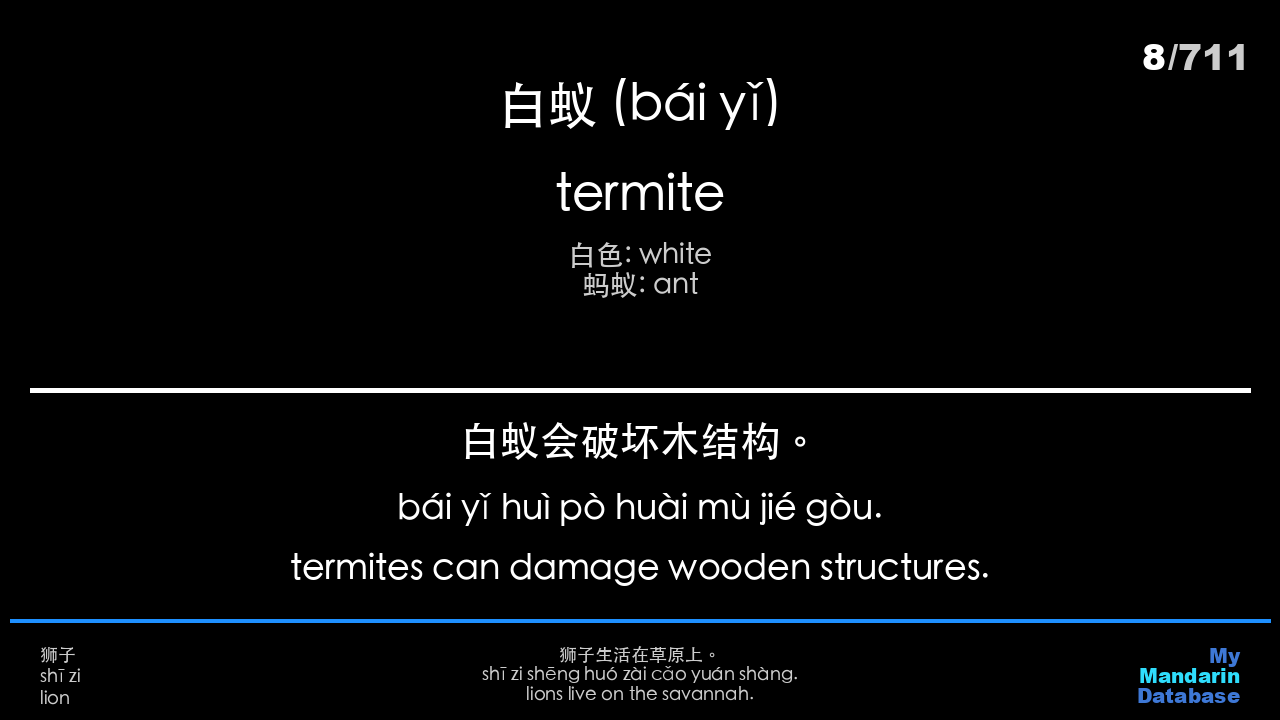

In [16]:
# Overall initializations
clips = []
previous_word = ''
previous_sent = ''

# Create folder to hold slide images
slides_path = f"{project_artifacts_folder}/slides"
if not os.path.exists(slides_path):
    os.mkdir(slides_path)

# Fill in defaults for any missing properties
for config_key, default_config_value in DEFAULT_TEXT_PROPERTIES.items():
    for vocab_slide_id, vocab_slide_settings in video_configs['vocab_slide'].items():
        if config_key not in vocab_slide_settings.keys():
            video_configs['vocab_slide'][vocab_slide_id][config_key] = default_config_value

# Iterate through each word
df_audio_durations_words_only = df_vocab_audio_durations.dropna(subset='sum_theory').reset_index(drop=True)
for word_idx, row in df_audio_durations_words_only.iterrows():
    # Initialize image
    print(f'Drawing {word_idx}: {row["chinese"]}')
    current_image_file_path = f"{slides_path}/{row['chinese']}"
    img = Image.new("RGB", video_configs['bg_size'], color=video_configs['bg_color'])
    draw = ImageDraw.Draw(img)
    
    # Header/Footer texts
    draw_word_index(draw, video_configs, n_vocab, word_idx)
    if 'logo' in video_configs.keys():
        draw_logo(draw, video_configs)
    if 'previous_word' in video_configs.keys():
        draw_previous_word(draw, video_configs, previous_word)
    if 'previous_sent' in video_configs.keys():
        draw_previous_sent(draw, video_configs, previous_sent)
    draw.line([
        (video_configs['footer_line']['x'], video_configs['bg_size'][1] - video_configs['footer_line']['y']),
        (video_configs['bg_size'][0] - video_configs['footer_line']['x'], video_configs['bg_size'][1] - video_configs['footer_line']['y'])],
        fill=video_configs['footer_line']['color'],
        width=video_configs['footer_line']['width'],
        joint=None)
    
    # Update previous
    previous_word = f"{row['chinese']}\n{row['pinyin']}\n{row['english']}"
    if 'previous_sent' in video_configs.keys():
        previous_sent = f"{row['sentence']}\n{row['sentence_pinyin']}\n{row['sentence_english']}"

    # Draw vocab depending on recording ID
    draw_vocab_based_on_format(data_settings['recording_id'], row, video_configs, current_image_file_path, img, draw, clips)

my_img = clips[23]
my_img.display_in_notebook()

# 7. Create non-vocab slides


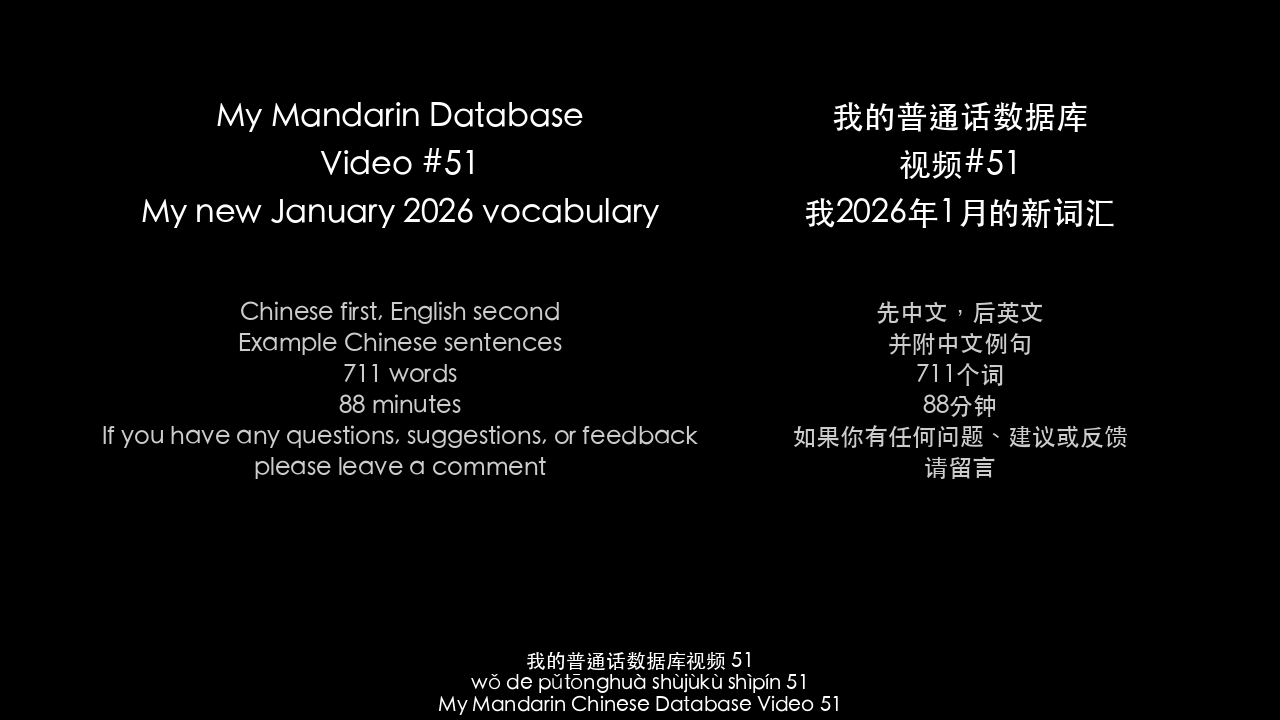

In [17]:
if nonvocab_slides is not None:
    if 'intro' in nonvocab_slides.keys():
        img = generate_intro_slide(video_configs, nonvocab_slides['intro'], subtitle_text_configs, audio_filler_variables)
        img.save(f"{project_artifacts_folder}/intro.png")
        my_img = ImageClip(f"{project_artifacts_folder}/intro.png", duration=1).with_start(0)
my_img.display_in_notebook()


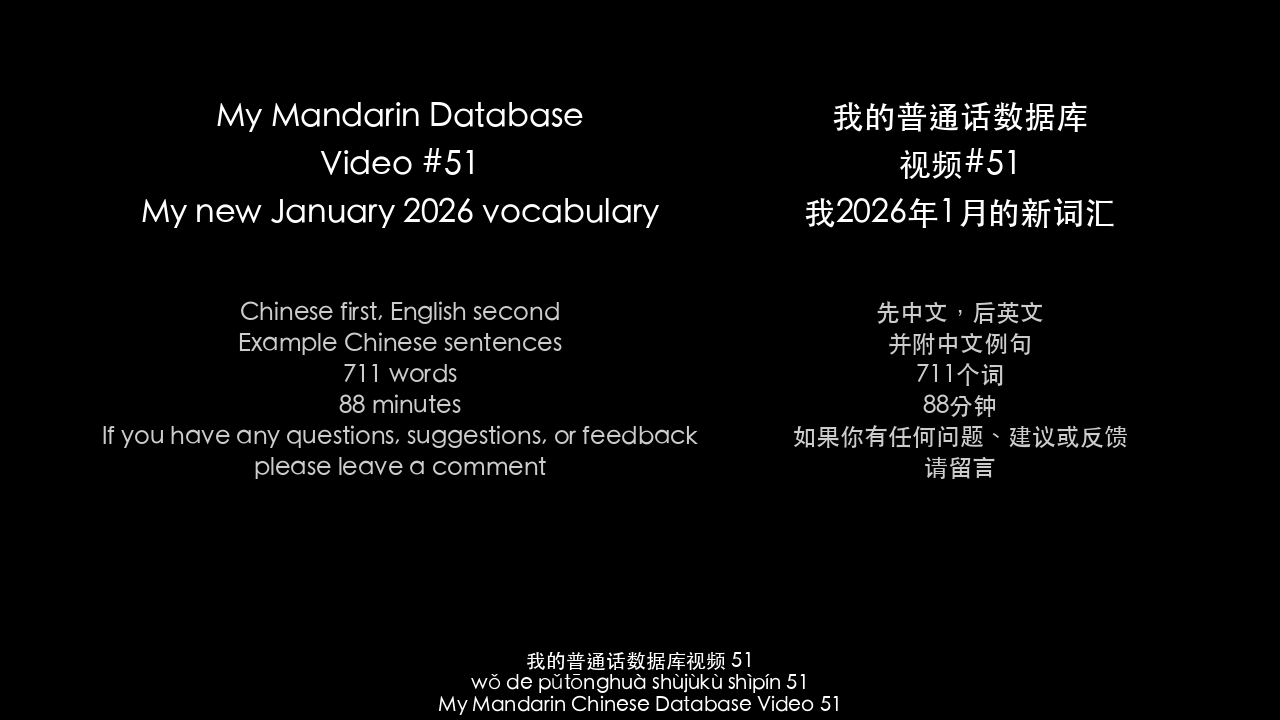

In [18]:
if nonvocab_slides is not None:
    if 'word_list' in nonvocab_slides.keys():
        img = generate_word_list_slide(video_configs, nonvocab_slides['word_list'], subtitle_text_configs, df_audio_durations_words_only)
        img.save(f"{project_artifacts_folder}/word_list.png")
        my_img = ImageClip(f"{project_artifacts_folder}/word_list.png", duration=1).with_start(0)
my_img.display_in_notebook()

In [19]:
# nonvocab_slides['outro'] = {
#         'chinese': '如果你有任何问题、建议或反馈，请留言。请点赞并订阅。',
#         'pinyin': 'Rúguǒ nǐ yǒu rènhé wèntí, jiànyì huò fǎnkuì, qǐng liúyán. Qǐng diǎn zàn bìng dìngyuè.',
#         'english': 'If you have any questions, suggestions, or feedback, please leave a comment. Please like and subscribe.',
#         'clip_index': -1,
#         'change_index': None,
#         'pause_ms': 500,

#         'y_top': 10,
#         'y_bottom': 70,
#         'x_top': 10,
#         'spacing': 0,
#         'font_size': 8,
#         'fill': '#FFFFFF',
#         'align': 'left',
#         'col_space': 0,
#         'col_space_big': 0,
#         'definition_configs':{
#             'chinese': {'x_offset': 0, 'x_max': 30, 'font_path': hanzi_font_path},
#             'pinyin': {'x_offset': None, 'x_max': 55, 'font_path': hanzi_font_path},
#             'english': {'x_offset': None, 'x_max': 55, 'font_path': hanzi_font_path},
#         }
# }

reduced font size to 7
reduced font size to 7
reduced font size to 6
reduced font size to 7
reduced font size to 6
reduced font size to 7
reduced font size to 7
reduced font size to 7
reduced font size to 7
reduced font size to 7
reduced font size to 6
reduced font size to 7
reduced font size to 6
reduced font size to 7
reduced font size to 6
reduced font size to 5
reduced text to biān jìng mù yáng quǎ
reduced font size to 7
reduced font size to 6
reduced font size to 7
reduced font size to 6
reduced font size to 5
reduced font size to 7
reduced font size to 6
reduced font size to 7
reduced font size to 7
reduced font size to 7
reduced font size to 6
reduced font size to 7
reduced font size to 7
reduced font size to 6
reduced font size to 7
reduced font size to 6
reduced font size to 7
reduced font size to 6
reduced font size to 5
reduced font size to 7
reduced font size to 6
reduced font size to 5
reduced text to hong kong–zhuhai–macau bridg
reduced text to hong kong–zhuhai–macau brid


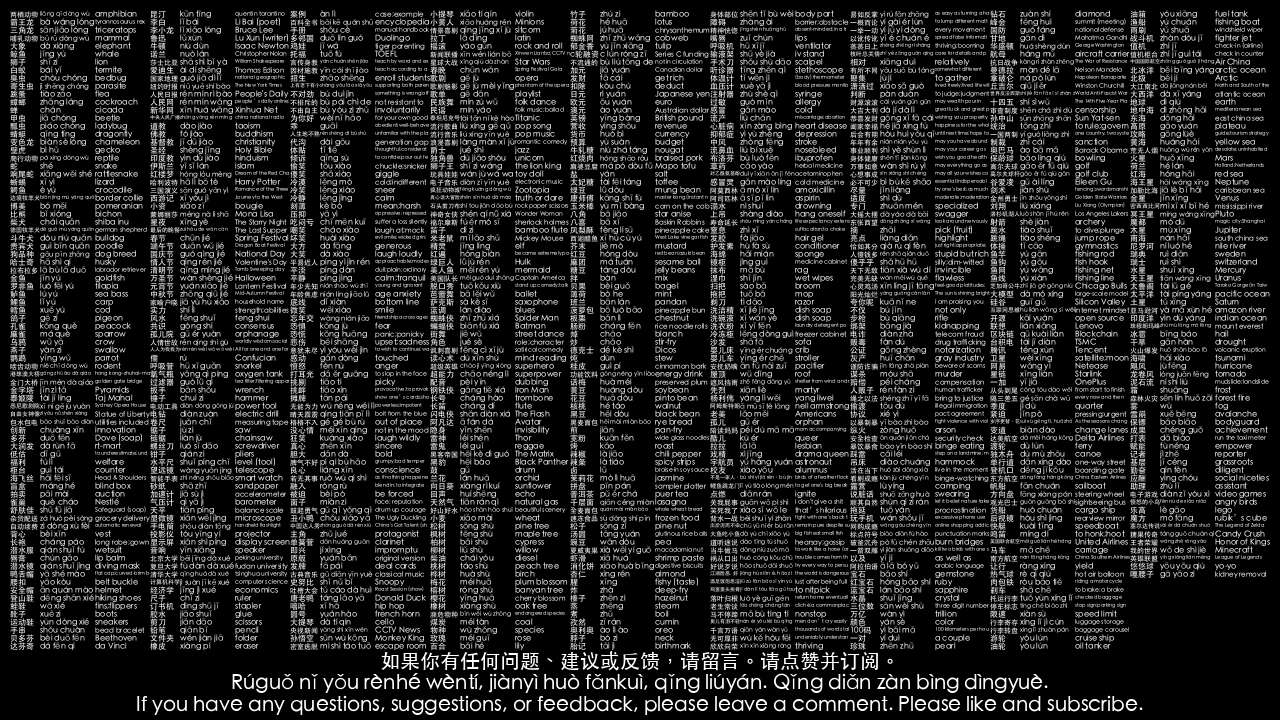

In [20]:
if nonvocab_slides is not None:
    if 'outro' in nonvocab_slides.keys():
        img = generate_outro_slide(video_configs, nonvocab_slides['outro'], subtitle_text_configs, df_audio_durations_words_only)
        img.save(f"{project_artifacts_folder}/outro.png")
        my_img = ImageClip(f"{project_artifacts_folder}/outro.png", duration=1).with_start(0)
my_img.display_in_notebook()

# 8. Create video icon


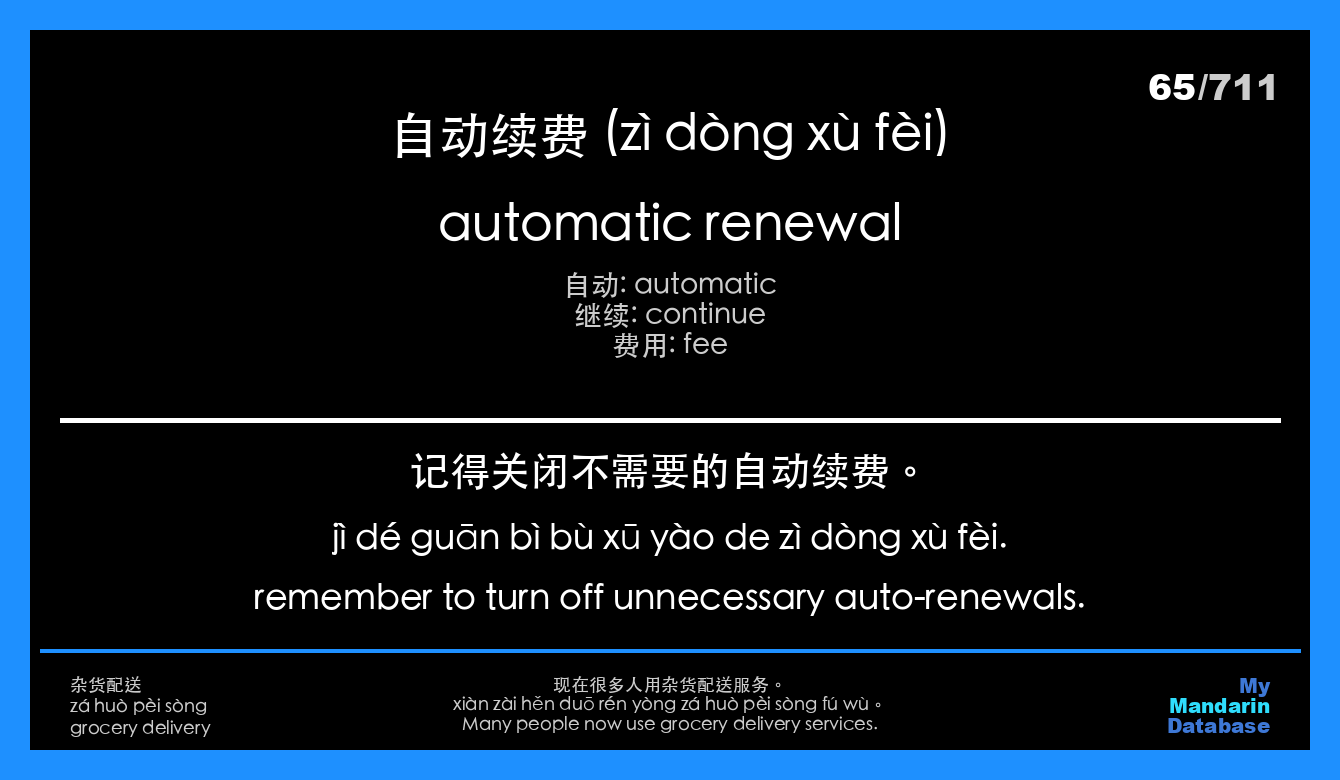

In [21]:
if 'icon_configs' in video_configs.keys():
    img = create_icon_from_slide(video_configs['icon_configs'], video_configs, project_artifacts_folder)
    img.save(f'{project_artifacts_folder}/icon.png')
    my_img = ImageClip(f"{project_artifacts_folder}/icon.png", duration=1).with_start(0)
my_img.display_in_notebook()

# 9. Create video

In [22]:
combine_clips_with_audio_to_create_video(clips, nonvocab_slides, project_artifacts_folder, data_settings)

intro
outro
Number of clips: 2135
audio: 5296.820s, video: 5296.762s; difference: 0.058s
MoviePy - Building video output/videos/0202_ce_csent_2026jan_words/video_2026jan_words.mp4.
MoviePy - Writing audio in video_2026jan_wordsTEMP_MPY_wvf_snd.mp3


MoviePy - Done.
MoviePy - Writing video output/videos/0202_ce_csent_2026jan_words/video_2026jan_words.mp4



MoviePy - Done !
MoviePy - video ready output/videos/0202_ce_csent_2026jan_words/video_2026jan_words.mp4
